In [1]:
import numpy as np
import h5py
import time

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from dataset_generation.noise_psd_gen import *
from helpers.config import *
from scipy.stats import truncnorm

import warnings
warnings.filterwarnings("ignore")

/opt/anaconda3/envs/gwaves_lisa_py311/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "text.usetex": False,
    "font.family": "serif"
})

## Figure 1

In [3]:
params = np.loadtxt(lpf_ord_param_path, skiprows=1)

lpf_betas = params[:, 0]
lpf_levels = params[:, 1]

bet_min = 1
amp_min, amp_max = 1e-16, 1e-10

lpf_levels = lpf_levels[lpf_betas > bet_min]
lpf_betas = lpf_betas[lpf_betas > bet_min]

lpf_betas = lpf_betas[(lpf_levels > amp_min) & (lpf_levels < amp_max)]
lpf_levels = lpf_levels[(lpf_levels > amp_min) & (lpf_levels < amp_max)]

In [4]:
with h5py.File(glitch_lm_dataset_path, "r") as h5:
    amp_array = h5["amp"][:]
    beta_array = h5["beta"][:]

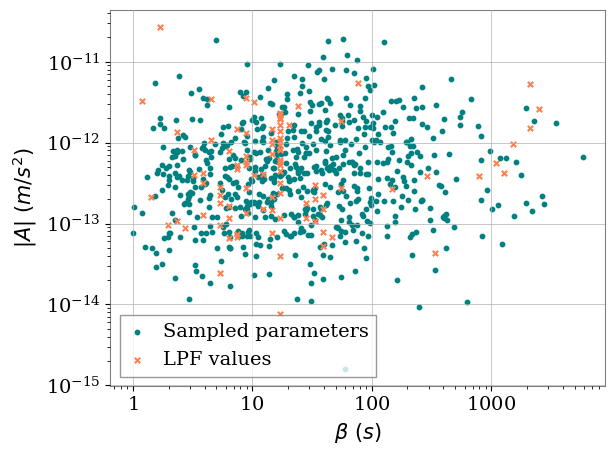

In [5]:
plt.figure(tight_layout=True)
plt.scatter(beta_array, amp_array, color='teal', s=10, label='Sampled parameters')
plt.scatter(lpf_betas, np.abs(lpf_levels), color='coral', s=15, marker='x', label='LPF values')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('$|A|\ (m/s^2)$')
plt.xlabel('$\\beta\ (s)$')
plt.legend()
plt.savefig(DIST/'figures'/'glitch_params.png')
plt.show()

## Figure 2

In [6]:
with h5py.File(orbits_path, 'r') as orb:
    orb_t0 = orb.attrs['t0']
    orb_size = orb.attrs['size']
    orb_dt = orb.attrs['dt']

pipe = {'t0': orb_t0 + orb_size*orb_dt/2, 'dt': 0.25,'size': int(15 * 3600 / 0.25),
        't_inj': 5 * 3600, 'keep_noises': ['test-mass', 'oms']}

glitches, gws = [], []
    
run_simulation(gws, glitches, pipe,
                None, None, orbits_path,
                simulation_path,
                disable_noise=pipe['keep_noises'])
tdi_dict = run_tdi(simulation_path, pipe)

X, Y, Z = tdi_dict['X'].value, tdi_dict['Y'].value, tdi_dict['Z'].value
A = (Z - X)/np.sqrt(2)
E = (X - 2*Y + Z)/np.sqrt(6)
T = (X + Y + Z)/np.sqrt(3)

Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


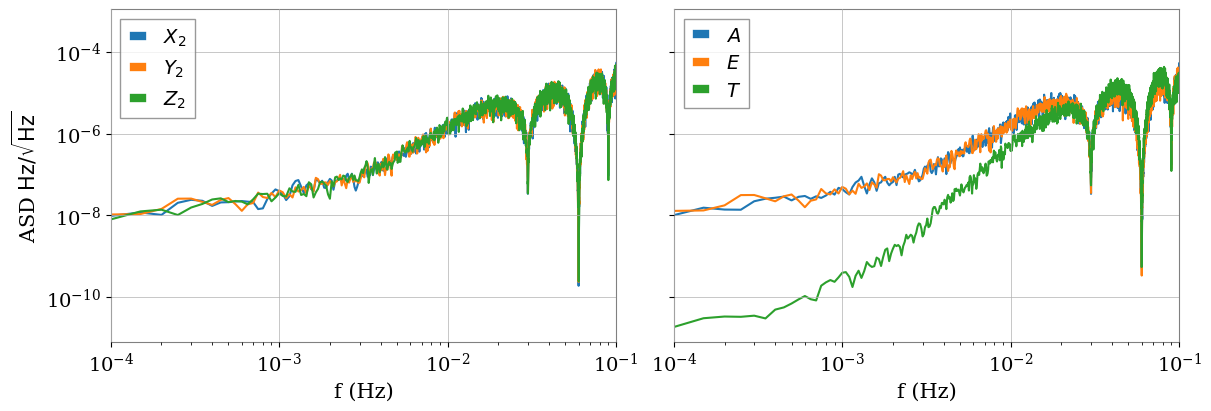

In [11]:
nperseg = 2e4/pipe['dt']
noverlap = None

SX_sim = estimate_psd(X, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
SY_sim = estimate_psd(Y, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
SZ_sim = estimate_psd(Z, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)

SA_sim = estimate_psd(A, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
SE_sim = estimate_psd(E, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)
ST_sim = estimate_psd(T, 1/pipe['dt'], nperseg=nperseg, noverlap=noverlap)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True, constrained_layout=True)

axes[0].loglog(SX_sim[0], np.sqrt(SX_sim[1]), label='$X_2$')
axes[0].loglog(SY_sim[0], np.sqrt(SY_sim[1]), label='$Y_2$')
axes[0].loglog(SZ_sim[0], np.sqrt(SZ_sim[1]), label='$Z_2$')

axes[1].loglog(SA_sim[0], np.sqrt(SA_sim[1]), label='$A$')
axes[1].loglog(SE_sim[0], np.sqrt(SE_sim[1]), label='$E$')
axes[1].loglog(ST_sim[0], np.sqrt(ST_sim[1]), label='$T$')

axes[0].set_xlabel('f (Hz)')
axes[0].set_ylabel('ASD $\\text{Hz}/\sqrt{\\text{Hz}}$')
axes[0].set_xlim(1e-4, 1e-1)
axes[0].legend()

axes[1].set_xlabel('f (Hz)') 
axes[1].set_xlim(1e-4, 1e-1)
axes[1].legend()

plt.savefig(FIGURES / 'noise_psd.png')
plt.show()

## Figure 3

In [200]:
gws = [{'type': 'BinaryInspiralGW', 'm1': 6e6, 'm2': 7e6, 'd': 1e3,
        'spin1': 0, 'spin2': 0, 't_inj': pipe['t_inj']+1*3600, 'domain': 'freq',
        'gw_beta':0, 'gw_lambda':0}]
glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': pipe['t_inj']-1*3600, 'beta':17,
             'level':2*2.28e-12*17, 'inj_point':'tm_13'}]

run_simulation(
            gws, glitches, pipe,
            gw_path, glitch_path, orbits_path,
            simulation_path,
            disable_noise=pipe['keep_noises']
        )
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [201]:
event = {'t_inj':pipe['t_inj']}
res = 256
spec = SPECS['ext_high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
QT_mixed = np.zeros((256, 256, 3))
for channel in ['A', 'E', 'T']:
    t_mixed, f_mixed, data = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
    QT_mixed[:, :, ['A', 'E', 'T'].index(channel)] = data
end = time.time()
print(end - start)

0.5583529472351074


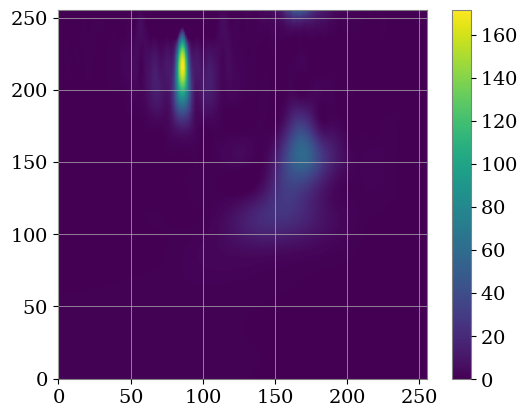

In [202]:
plt.imshow(QT_mixed[:, :, 0], origin='lower')
#plt.clim(0, 60)
plt.colorbar()
plt.show()

In [204]:
with h5py.File(gw_lm_dataset_path, "r") as h5:
    QT_gw_images = h5["QT"][25][:]
    t_gw_arr = h5["t_qscan"][25][:]
    f_gw_arr = h5["f_qscan"][25][:]

with h5py.File(glitch_hm_dataset_path, "r") as h5:
    QT_glitch_images = h5["QT"][25][:]
    t_glitch_arr = h5["t_qscan"][25][:]
    f_glitch_arr = h5["f_qscan"][25][:]

with h5py.File(empty_ehm_dataset_path, "r") as h5:
    QT_empty_images = h5["QT"][25][:]
    t_empty_arr = h5["t_qscan"][25][:]
    f_empty_arr = h5["f_qscan"][25][:]

In [235]:
channels = ['A', 'E', 'T']

QT_gw, t_gw, f_gw = QT_gw_images[4], t_gw_arr[4], f_gw_arr[4]
QT_glitch, t_glitch, f_glitch = QT_glitch_images[1], t_glitch_arr[1], f_glitch_arr[1]
QT_empty, t_empty, f_empty = QT_empty_images[0], t_empty_arr[0], f_empty_arr[0]
#QT_mixed, t_mixed, f_mixed = QT_mixed_images[2], t_mixed_arr[2], f_mixed_arr[2]

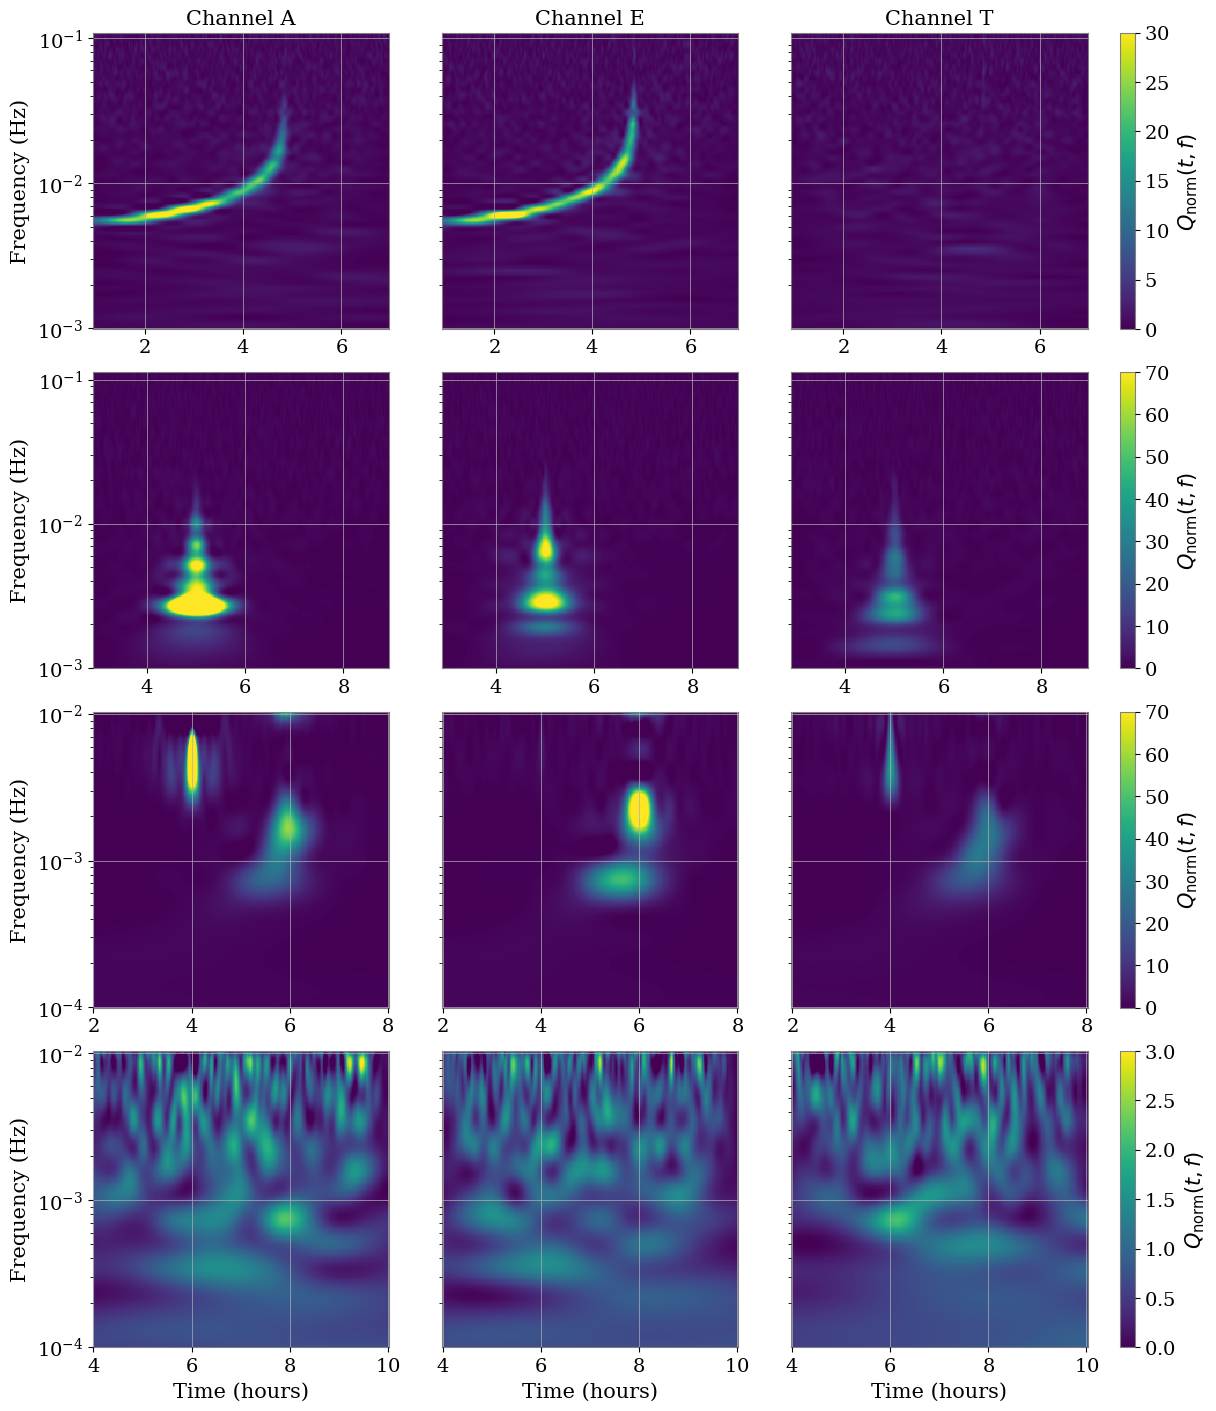

In [236]:
shrink = 1
fig, axes = plt.subplots(4, 3, figsize=(12,14), constrained_layout=True)

# share y within rows
for row in axes:
    for ax in row[1:]:
        ax.sharey(row[0])
        ax.tick_params(left=False, labelleft=False)

# ---------- ROW 0: GW ----------
ims = []
for i, ax in enumerate(axes[0, :]):
    ax.set_box_aspect(1)
    ax.set_yscale('log')
    im = ax.pcolormesh(t_gw/3600, f_gw, QT_gw[:,:,i], cmap='viridis',\
                        vmin=0, vmax=30)
    ims.append(im)
    
    ax.set_title(f'Channel {channels[i]}')
    if i == 0:
        ax.set_ylabel('Frequency (Hz)')

# ONE colorbar for whole row
fig.colorbar(ims[-1], ax=axes[0, :], fraction=0.02, pad=0.02, shrink=shrink, label='$Q_{\\text{norm}}(t,f)$')


# ---------- ROW 1: GLITCH ----------
ims = []
for i, ax in enumerate(axes[1, :]):
    ax.set_box_aspect(1)
    ax.set_yscale('log')
    im = ax.pcolormesh(t_glitch/3600, f_glitch, QT_glitch[:,:,i], cmap='viridis',\
                        vmin=0, vmax=70)
    ims.append(im)
    
    if i == 0:
        ax.set_ylabel('Frequency (Hz)')

fig.colorbar(ims[-1], ax=axes[1, :], fraction=0.02, pad=0.02, shrink=shrink, label='$Q_{\\text{norm}}(t,f)$')


# ---------- ROW 2: MIXED ----------
ims = []
for i, ax in enumerate(axes[2, :]):
    ax.set_box_aspect(1)
    ax.set_yscale('log')
    im = ax.pcolormesh(t_mixed/3600, f_mixed, QT_mixed[:,:,i], cmap='viridis',\
                        vmin=0, vmax=70)
    ims.append(im)
    
    if i == 0:
        ax.set_ylabel('Frequency (Hz)')

fig.colorbar(ims[-1], ax=axes[2, :], fraction=0.02, pad=0.02, shrink=shrink, label='$Q_{\\text{norm}}(t,f)$')


# ---------- ROW 3: EMPTY ----------
ims = []
for i, ax in enumerate(axes[3, :]):
    ax.set_box_aspect(1)
    ax.set_yscale('log')
    im = ax.pcolormesh(t_empty/3600, f_empty, QT_empty[:,:,i], cmap='viridis',\
                        vmin=0, vmax=3)
    ims.append(im)
    
    ax.set_xlabel('Time (hours)')
    if i == 0:
        ax.set_ylabel('Frequency (Hz)')

fig.colorbar(ims[-1], ax=axes[3, :], fraction=0.02, pad=0.02, shrink=shrink, label='$Q_{\\text{norm}}(t,f)$')
plt.savefig(FIGURES / 'example_qscans.png')
plt.show()